In [23]:
# data and imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
pattern = os.path.join(filepath, "CRMLSSold*.csv")
files = sorted(glob.glob(pattern))

for f in files:
    print(os.path.basename(f))

f1 = pd.read_csv(filepath + r"\CRMLSSold202407_filled.csv", low_memory=False)
f2 = pd.read_csv(filepath + r"\CRMLSSold202408.csv", low_memory=False)

#removing the two columns from f1 that aren't in f2 to help remove nan issues in the future, I don't anticipate using these columns, can easily be undone by reloading data i
combined = pd.concat([f1, f2], ignore_index=True)
data = combined.drop(columns=['latfilled', 'lonfilled'])
dupes = combined[data.duplicated(keep=False)]



CRMLSSold20220101_20231231_filled.csv
CRMLSSold202401_filled.csv
CRMLSSold202402_filled.csv
CRMLSSold202403_filled.csv
CRMLSSold202406_filled.csv
CRMLSSold202407_filled.csv
CRMLSSold202408.csv
CRMLSSold202409.csv
CRMLSSold202410.csv
CRMLSSold202411.csv
CRMLSSold202412.csv


In [24]:
#applying data filter

filtered_data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')].copy()
print(filtered_data.shape)

(25811, 78)


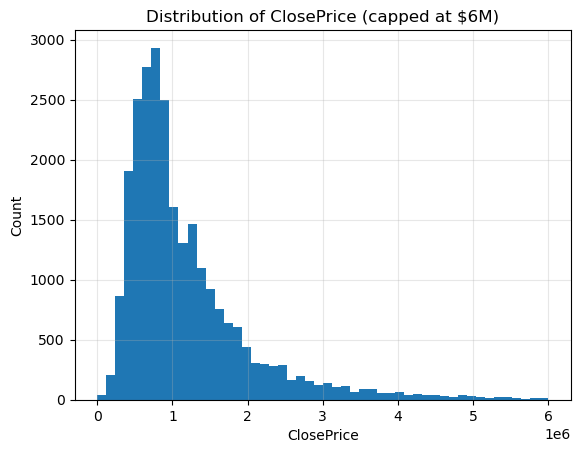

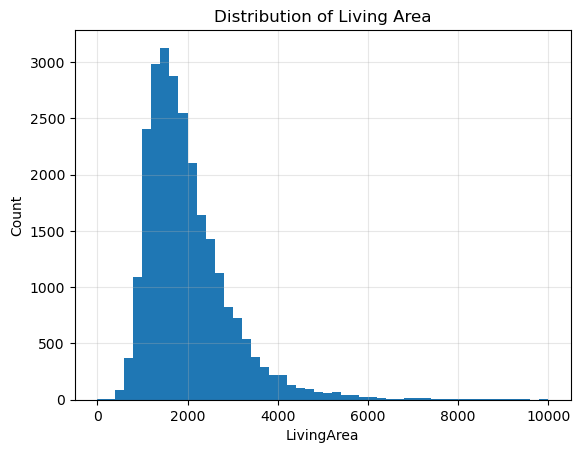

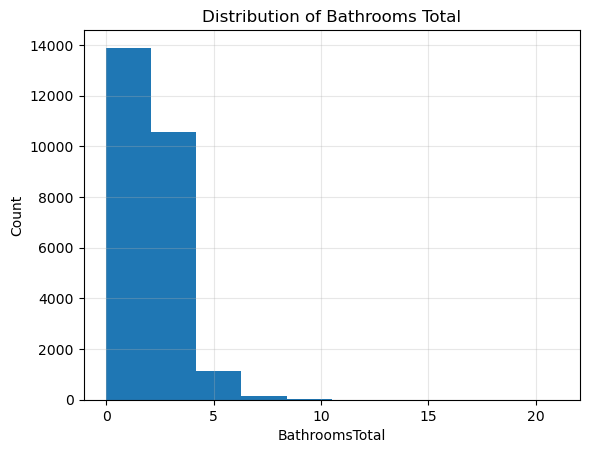

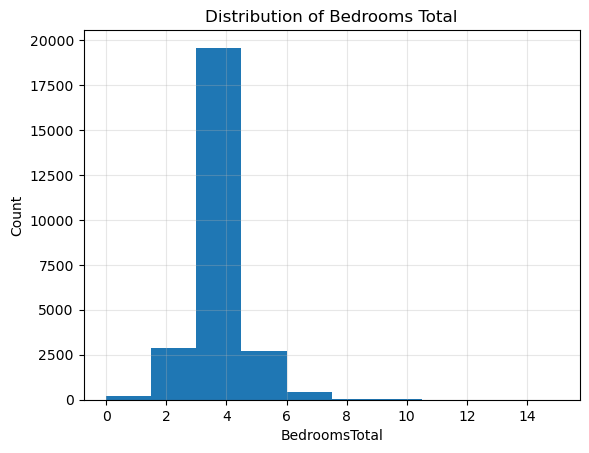

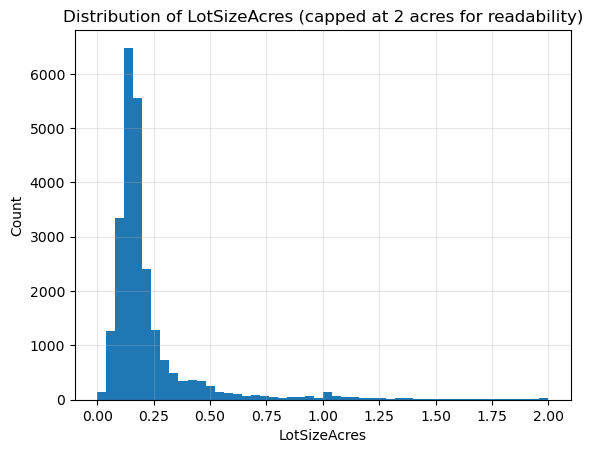

In [90]:
#histograms of data

# close price
filtered_data['ClosePrice'].hist(bins=50, range=(0, 6_000_000)) #capped price to make visualizaton better - some houses are way above average
plt.xlabel('ClosePrice')
plt.ylabel('Count')
plt.title('Distribution of ClosePrice (capped at $6M)')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# living area
filtered_data['LivingArea'].hist(bins=50, range=(0, 10000))
plt.xlabel('LivingArea')
plt.ylabel('Count')
plt.title('Distribution of Living Area')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bathrooms
filtered_data['BathroomsTotalInteger'].hist()
plt.xlabel('BathroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bathrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bedrooms
filtered_data['BedroomsTotal'].hist()
plt.xlabel('BedroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bedrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# lot size
filtered_data['LotSizeAcres'].hist(bins=50, range=(0, 2))
plt.xlabel('LotSizeAcres')
plt.ylabel('Count')
plt.title('Distribution of LotSizeAcres (capped at 2 acres for readability)')
plt.grid(alpha=0.3)
plt.show()
plt.close()